# LDA Topic Analysis of Model Explanations
## Gender × Emotion Experiment — Vision Transformer Interestingness Study

This notebook documents how LDA (Latent Dirichlet Allocation) topics are derived
from the model's free-text explanations, then traces those topics through the
model's internal activation space.

**Contents**
1. [LDA Topic Derivation](#1.-LDA-Topic-Derivation) — preprocessing, vocabulary, parameters, topic words
2. [Topic Assignment per Image](#2.-Topic-Assignment-per-Image) — dominant topics, stability across conditions
3. [Topics in Point Clouds](#3.-Topics-in-Point-Clouds) — UMAP/t-SNE colored by topic vs label
4. [Layer Persistence](#4.-Layer-Persistence) — at which layer do topic clusters emerge and stabilise?
5. [Image Galleries by Topic](#5.-Image-Galleries-by-Topic) — visual inspection of each topic cluster
6. [Vision-Space Validation](#6.-Vision-Space-Validation) — do LDA topics align with visual feature clusters?

**Note on visual artefacts (§6):** LDA topics are derived purely from text.
Section 6 cross-validates them against the model's vision encoder activations
to check whether semantically similar explanations also cluster in visual space.


In [1]:
import os, re, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import silhouette_score
from collections import defaultdict, Counter

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
GE_DIR      = 'data/experiments/gender_emotion'
METRICS_DIR = 'results/experiments/metrics'
IMG_DIR     = 'data/imagesDemographics'
LDA_DIR     = 'results/experiments/gender_emotion_analysis/lda'

EXPERIMENTS = [
    'female_anger', 'female_fear', 'female_disgust', 'female_sad',
    'female_amusement', 'female_awe', 'female_contentment',
    'female_excitement', 'male_anger',
]
SHORT = {
    'female_anger': 'F-Anger',    'female_fear': 'F-Fear',
    'female_disgust': 'F-Disgust','female_sad': 'F-Sad',
    'female_amusement': 'F-Amus', 'female_awe': 'F-Awe',
    'female_contentment': 'F-Con','female_excitement': 'F-Exc',
    'male_anger': 'M-Anger',
}
LABEL_ORDER = [
    'Not Interesting', 'Slightly Interesting', 'Moderately Interesting',
    'Very Interesting', 'Extremely Interesting',
]
LABEL_SCORE  = {l: i for i, l in enumerate(LABEL_ORDER)}
LABEL_COLORS = dict(zip(LABEL_ORDER, ['#d62728','#ff7f0e','#1f77b4','#2ca02c','#9467bd']))

N_TOPICS = 10
TOPIC_CMAP = plt.colormaps['tab10']
TOPIC_COLORS = [TOPIC_CMAP(t / N_TOPICS) for t in range(N_TOPICS)]


In [3]:
# ── Load LDA artefacts ────────────────────────────────────────────────────────
with open(f'{LDA_DIR}/lda_artefacts.pkl', 'rb') as f:
    arts = pickle.load(f)

lda         = arts['lda']
vectorizer  = arts['vectorizer']
topic_words = arts['topic_words']   # list of lists, one per topic
df_meta     = arts['df_meta']       # (4500, 17): image_idx, condition, label, topic_0..9

topic_cols  = [f'topic_{t}' for t in range(N_TOPICS)]

print(f"LDA model:   {N_TOPICS} topics")
print(f"Vocabulary:  {len(vectorizer.get_feature_names_out())} tokens")
print(f"df_meta:     {df_meta.shape}  (n_images × n_conditions = 500 × 9)")
print()
for t, words in enumerate(topic_words):
    print(f"T{t+1:02d}:  {', '.join(words[:8])}")


LDA model:   10 topics
Vocabulary:  520 tokens
df_meta:     (4500, 17)  (n_images × n_conditions = 500 × 9)

T01:  unique, woman, unusual, combination, pose, blend, setting, urban
T02:  flower, flowers, playing, unique, station, color, pleasant, intricate
T03:  child, display, field, historical, military, walking, event, music
T04:  vibrant, car, bird, colors, work, right, appealing, calming
T05:  unique, building, design, architecture, vintage, flight, appreciate, fully
T06:  unusual, dog, unique, moderately, appearance, moderate, dynamic, natural
T07:  man, person, setting, winter, mountain, cultural, traditional, food
T08:  serene, calm, landscape, calmness, water, awe, sunset, atmosphere
T09:  people, casual, group, event, setting, young, lively, everyday
T10:  old, train, nostalgia, statue, history, background, street, historic


In [4]:
# ── Load GDV / projection data for all experiments ───────────────────────────
gdv_data = {}
for exp in EXPERIMENTS:
    key = f'gender_{exp}'
    path = f'{METRICS_DIR}/{key}/gdv.pkl'
    with open(path, 'rb') as f:
        gdv_data[exp] = pickle.load(f)

# Helper: get UMAP coords and ordered filenames for (experiment, layer, umap_setup_idx)
def get_projection(exp, layer_key, proj_type='umap', setup_idx=0):
    info = gdv_data[exp]['layer_data'][layer_key]
    proj_dict = info['projections'][proj_type]
    if not proj_dict:
        return None, None
    key = list(proj_dict.keys())[setup_idx]
    coords = np.array(proj_dict[key]['coords'])
    filenames = info['samples']['filenames']
    return coords, filenames

# Convenience: per-experiment best vision GDV layer
best_vision_layer = {}
for exp in EXPERIMENTS:
    gdv_vl = {k: v for k, v in gdv_data[exp]['gdv_per_layer'].items() if k.startswith('vision')}
    best_vision_layer[exp] = max(gdv_vl, key=gdv_vl.get)

print("Best vision layer per experiment:")
for e, l in best_vision_layer.items():
    gdv = gdv_data[e]['gdv_per_layer'][l]
    print(f"  {SHORT[e]:<10}  {l:<25}  GDV={gdv:.4f}")


Best vision layer per experiment:
  F-Anger     vision_1_D1408             GDV=0.0677
  F-Fear      vision_32_D1408            GDV=0.0842
  F-Disgust   vision_32_D1408            GDV=0.0833
  F-Sad       vision_2_D1408             GDV=0.0653
  F-Amus      vision_1_D1408             GDV=0.0557
  F-Awe       vision_9_D1408             GDV=0.0581
  F-Con       vision_32_D1408            GDV=0.0654
  F-Exc       vision_5_D1408             GDV=0.0577
  M-Anger     vision_1_D1408             GDV=0.0657


---
## 1. LDA Topic Derivation

### 1.1 Why per-image meta-documents?

Each individual explanation averages **~17 words** after cleaning — far too short
for stable LDA inference (the model has little context to estimate topic mixtures).

**Solution:** for each of the 500 images, concatenate its explanations across
all 9 conditions into a single *meta-document* (~83 content words).  We then:
1. **Fit** LDA on these 500 meta-documents → topics reflect image content, not condition framing.
2. **Transform** each individual explanation through the fitted model → per-condition topic weights.

This separation means topic vocabulary captures *what is in the image*, while
the per-condition weights capture *how much the model foregrounds that theme under each emotion persona*.


In [5]:
# Reproduce meta-doc construction to make the process explicit
_CLAUSE_PATTERNS = [
    r',\s*which\s+(?:is|are|was|were|could|might|may|doesn|don|isn|can|has|had|does)\b.*',
    r',\s*but\s+(?:it\s+)?(?:doesn|don|isn|can|couldn|wouldn)\b.*',
    r',\s*(?:contrasts?|resonates?|aligns?)\s+with\s+my\s+current.*',
    r'(?:due to|because of)\s+my\s+(?:current\s+)?\w+\s+(?:state|mood|feeling|situation)\b.*',
    r'my\s+current\s+\w+\s+(?:mood|state|feeling|situation)\b[^.]*',
    r'\bthe image does not evoke\b.*',
    r"doesn.?t evoke\s+(?:strong\s+)?(?:any\s+)?(?:emotions?|curiosity|interest|response)\b.*",
]
_RE = [re.compile(p, re.IGNORECASE) for p in _CLAUSE_PATTERNS]

def clean_text(text):
    for pat in _RE:
        text = pat.sub('', text)
    text = re.sub(r'\s{2,}', ' ', text)
    text = re.sub(r'\s*[,;]\s*$', '', text)
    return text.strip()

# Show a before/after example
results_sample = np.load(f'{GE_DIR}/results_female_anger.npy', allow_pickle=True).item()['results']
print("=== Cleaning examples ===\n")
for r in results_sample[2:6]:
    raw   = r['explanation']
    clean = clean_text(raw)
    print(f"RAW:   {raw}")
    print(f"CLEAN: {clean}")
    print()


=== Cleaning examples ===

RAW:   The image shows a professional scene with people shaking hands, which is a common but still somewhat engaging event.
CLEAN: The image shows a professional scene with people shaking hands

RAW:   The image shows a man speaking at a podium, which could be a common scene but might spark curiosity about the event or his message.
CLEAN: The image shows a man speaking at a podium

RAW:   The image does not evoke any strong emotions or curiosity in me right now.
CLEAN: 

RAW:   The image shows a young boy playing tennis, which is a mildly engaging scene.
CLEAN: The image shows a young boy playing tennis



### 1.2 Vocabulary filtering

Two-stage filter to suppress the model's evaluative scaffolding:

**Stage 1 — evaluative stopword list:** explicitly blocks template vocabulary
(`evoke/evokes`, `attention`, `curiosity`, `strong`, `emotion`, `mood`, etc.) and
persona-state emotion words (`anger/angry`, `disgust`, `sadness`, `fearful`, etc.)
that occur in the "contrasts with my current X mood" clause pattern.

**Stage 2 — corpus-level frequency cutoffs:**
- `min_df=5`: a word must appear in ≥ 5 images (removes misspellings and hapax legomena)
- `max_df=0.55`: a word appearing in > 55% of meta-docs is non-discriminative → dropped

Words that survive are predominantly **content nouns** (objects, settings, scene descriptors).


In [6]:
# Reproduce vocabulary stats to document what's in vs out
from sklearn.feature_extraction.text import CountVectorizer as CV

# Re-load raw results to rebuild meta-docs (for transparency)
records = defaultdict(list)
for exp in EXPERIMENTS:
    d = np.load(f'{GE_DIR}/results_{exp}.npy', allow_pickle=True).item()
    lkey = 'interestingness_label' if 'interestingness_label' in d['results'][0] else 'interestingness'
    for i, r in enumerate(d['results']):
        records[i].append(clean_text(r['explanation']))

meta_docs = [' '.join(records[i]) for i in range(500)]

# Stage 1: raw vectorizer
cv_raw = CV(min_df=5, max_df=0.55, ngram_range=(1,2), token_pattern=r'\b[a-zA-Z]{3,}\b')
cv_raw.fit(meta_docs)
vocab_raw = set(cv_raw.get_feature_names_out())

# Stage 2: apply evaluative stopword filter
with open('analysis_text_themes.py') as f:
    src = f.read()

import ast
# Read the EVALUATIVE_STOP set directly from the module
import importlib.util
spec = importlib.util.spec_from_file_location("ats", "analysis_text_themes.py")
ats = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ats)
EVAL_STOP = ats.EVALUATIVE_STOP

bad = {w for w in vocab_raw
       if any(tok in EVAL_STOP for tok in w.split())}
vocab_clean = vocab_raw - bad

print(f"Raw vocabulary (min_df=5, max_df=0.55):  {len(vocab_raw):>5} tokens")
print(f"Removed by evaluative stopword filter:    {len(bad):>5} tokens")
print(f"Final vocabulary:                         {len(vocab_clean):>5} tokens")
print()
print("Sample removed tokens (evaluative):")
sample_bad = sorted(list(bad))[:30]
print(" | ".join(sample_bad))
print()
print("Sample kept tokens (content):")
sample_good = [w for w in sorted(vocab_clean) if ' ' not in w][:40]
print(" | ".join(sample_good))


Raw vocabulary (min_df=5, max_df=0.55):   1385 tokens
Removed by evaluative stopword filter:      866 tokens
Final vocabulary:                           519 tokens

Sample removed tokens (evaluative):
about | about its | about potential | about the | about their | about what | about work | activity the | adventure and | adventure the | against the | aligning with | alleviated the | also | also makes | amusement the | amusing and | amusing scene | and adventure | and amusement | and amusing | and architecture | and attention | and awe | and beautiful | and beauty | and breathtaking | and calm | and calming | and calmness

Sample kept tokens (content):
abandoned | abandonment | abstract | activities | activity | adds | admiration | adorable | adventure | aesthetically | against | aligning | alleviated | alone | already | amusement | amusing | appeal | appealing | appearance | appetizing | appreciate | appreciating | architectural | architecture | area | around | art | artistic | atmosphe

### 1.3 LDA parameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `n_components` | 10 | ~8–12 expected semantic image categories in the AffectNet-adjacent stimulus set |
| `learning_method` | `'batch'` | Batch EM is more stable than online learning for N=500 meta-docs |
| `max_iter` | 50 | Enough iterations for batch EM to converge on a vocabulary of ~520 tokens |
| `doc_topic_prior` α | 0.1 | Sparse topic mixture — each image is expected to have 1–2 dominant themes |
| `topic_word_prior` β | 0.01 | Concentrated word distributions per topic — sharper, more interpretable topics |

The perplexity on held-out meta-docs was **132.5** (lower = better fit).


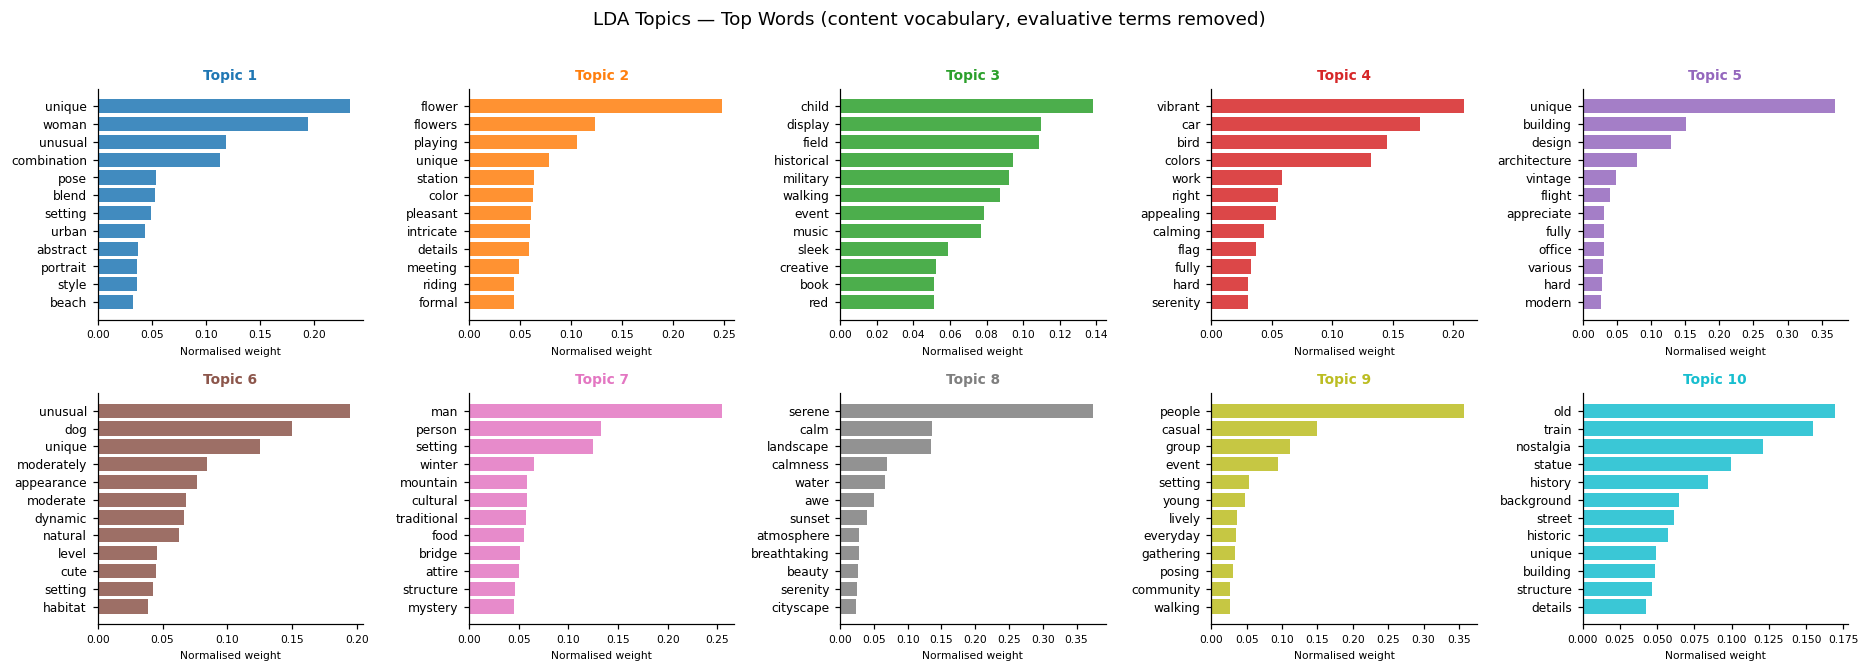

In [7]:
# Topic word bar charts — top 10 words per topic, normalised weight
n = N_TOPICS
ncols, nrows = 5, 2
vocab_arr = vectorizer.get_feature_names_out()

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3.4, nrows*3.0))
axes = axes.flatten()

for t, (words, ax) in enumerate(zip(topic_words, axes)):
    comp  = lda.components_[t]
    idxs  = np.array([np.where(vocab_arr == w)[0][0] for w in words if w in vocab_arr])
    wts   = comp[idxs]; wts /= wts.sum()
    ax.barh(range(len(words)), wts[::-1], color=TOPIC_COLORS[t], alpha=0.85)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words[::-1], fontsize=8)
    ax.set_xlabel('Normalised weight', fontsize=7)
    ax.set_title(f'Topic {t+1}', fontsize=9, fontweight='bold', color=TOPIC_COLORS[t])
    ax.tick_params(axis='x', labelsize=7)

plt.suptitle('LDA Topics — Top Words (content vocabulary, evaluative terms removed)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{LDA_DIR}/nb_topics_words.png', dpi=130, bbox_inches='tight')
plt.show()


---
## 2. Topic Assignment per Image

Each image's **dominant topic** is the argmax of its average topic weight across
all 9 conditions.  Averaging first removes condition-specific framing and keeps
only the image-content signal.


In [8]:
# Per-image average topic weight (mean over all 9 conditions)
img_topic_mean = df_meta.groupby('image_idx')[topic_cols].mean()
img_dominant   = img_topic_mean.idxmax(axis=1).str.replace('topic_', '').astype(int)  # 0-indexed

print("Dominant-topic distribution across 500 images:")
counts = img_dominant.value_counts().sort_index()
for t, cnt in counts.items():
    bar = '█' * cnt
    top3 = ', '.join(topic_words[t][:4])
    print(f"  T{t+1:02d} [{top3:<30}]  {cnt:>3} images  {bar}")


Dominant-topic distribution across 500 images:
  T01 [unique, woman, unusual, combination]   51 images  ███████████████████████████████████████████████████
  T02 [flower, flowers, playing, unique]   39 images  ███████████████████████████████████████
  T03 [child, display, field, historical]   26 images  ██████████████████████████
  T04 [vibrant, car, bird, colors    ]   57 images  █████████████████████████████████████████████████████████
  T05 [unique, building, design, architecture]   48 images  ████████████████████████████████████████████████
  T06 [unusual, dog, unique, moderately]   56 images  ████████████████████████████████████████████████████████
  T07 [man, person, setting, winter  ]   42 images  ██████████████████████████████████████████
  T08 [serene, calm, landscape, calmness]   92 images  ████████████████████████████████████████████████████████████████████████████████████████████
  T09 [people, casual, group, event  ]   65 images  ███████████████████████████████████████████

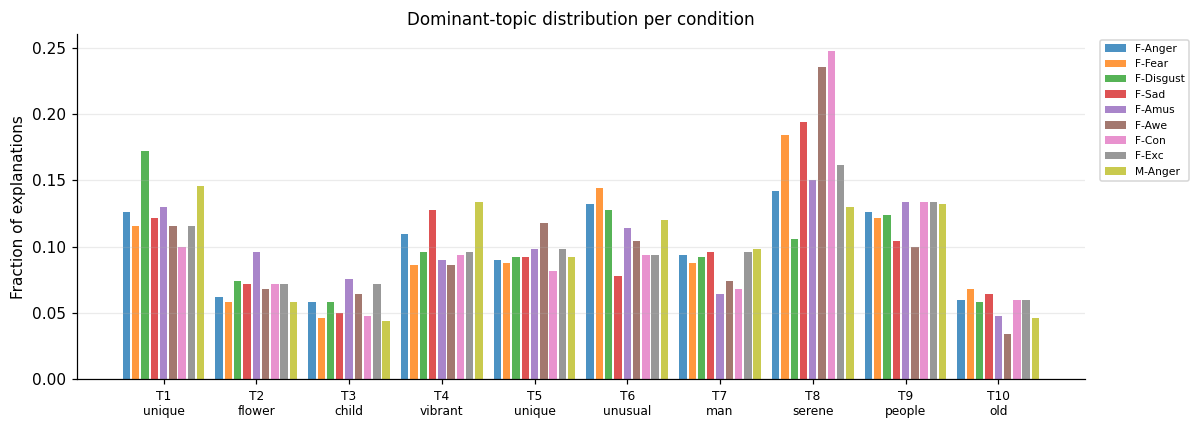

In [9]:
# Per-condition dominant topic distribution
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(N_TOPICS)
width = 0.08
offsets = np.linspace(-0.4, 0.4, len(EXPERIMENTS))

for i, exp in enumerate(EXPERIMENTS):
    sub = df_meta[df_meta['condition'] == exp]
    dom = sub[topic_cols].values.argmax(axis=1)
    counts = np.bincount(dom, minlength=N_TOPICS) / len(sub)
    ax.bar(x + offsets[i], counts, width=width, label=SHORT[exp], alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f'T{t+1}\n{topic_words[t][0]}' for t in range(N_TOPICS)], fontsize=8)
ax.set_ylabel('Fraction of explanations')
ax.set_title('Dominant-topic distribution per condition', fontsize=11)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(f'{LDA_DIR}/nb_topic_dist_per_condition.png', dpi=120, bbox_inches='tight')
plt.show()


Mean topic stability across conditions: 0.696
Images with 100% agreement:            105
Images with <55% agreement:            131


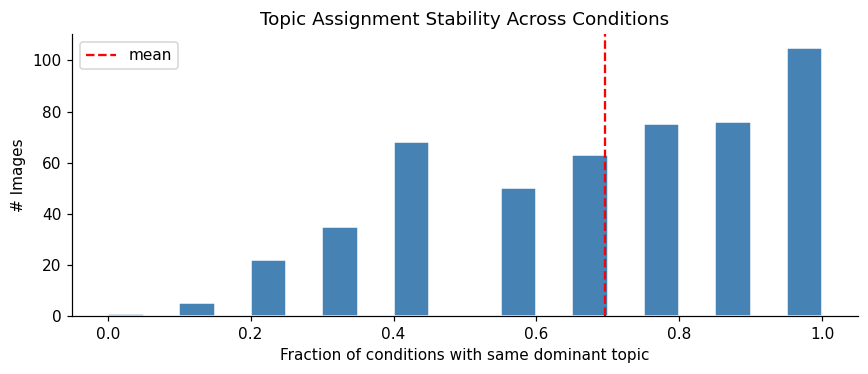

In [10]:
# Cross-condition topic stability: for each image, how consistently is
# the same topic dominant across the 9 conditions?
# Stability = fraction of conditions that agree with the overall dominant topic.

stability = []
for idx in range(500):
    sub = df_meta[df_meta['image_idx'] == idx]
    cond_dom = sub[topic_cols].values.argmax(axis=1)   # one per condition
    overall_dom = int(img_dominant[idx])
    agree = (cond_dom == overall_dom).mean()
    stability.append({'image_idx': idx,
                      'dominant_topic': overall_dom,
                      'stability': agree,
                      'filename': sub.iloc[0]['filename']})

df_stab = pd.DataFrame(stability)
print(f"Mean topic stability across conditions: {df_stab['stability'].mean():.3f}")
print(f"Images with 100% agreement:            {(df_stab['stability'] == 1.0).sum()}")
print(f"Images with <55% agreement:            {(df_stab['stability'] < 0.55).sum()}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(df_stab['stability'], bins=20, color='steelblue', edgecolor='white')
ax.axvline(df_stab['stability'].mean(), color='red', linestyle='--', label='mean')
ax.set_xlabel('Fraction of conditions with same dominant topic')
ax.set_ylabel('# Images')
ax.set_title('Topic Assignment Stability Across Conditions')
ax.legend()
plt.tight_layout()
plt.show()


---
## 3. Topics in Point Clouds

We overlay LDA topic assignments onto the UMAP projections stored in `gdv.pkl`.
If **topic-coloured** points cluster spatially, the model's internal representations
encode the same content structure that the text descriptions reveal — a positive
cross-modal consistency check.

We compare two colouring schemes side-by-side:
- **Left:** interestingness label (how the model rated the image)
- **Right:** dominant LDA topic (what the image is about, from text)


Showing: female_awe / vision_9_D1408  (GDV=0.0581)


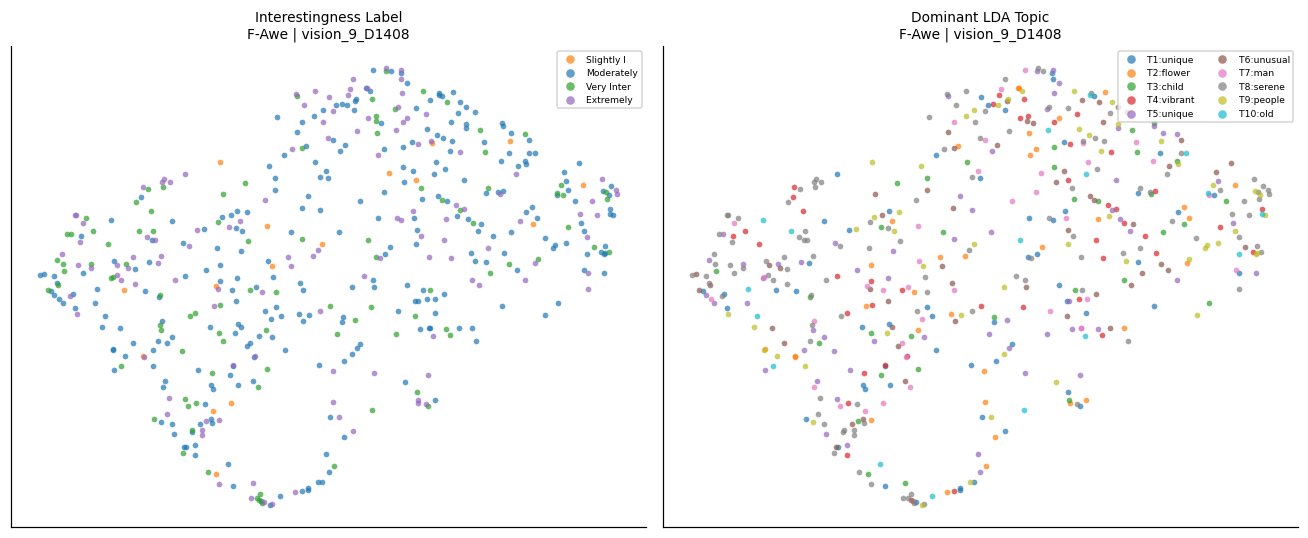

In [11]:
def plot_dual_projection(exp, layer_key, proj_type='umap', setup_idx=0, ax_pair=None):
    """Side-by-side: label-coloured vs topic-coloured UMAP/t-SNE."""
    coords, fnames = get_projection(exp, layer_key, proj_type, setup_idx)
    if coords is None:
        print(f"No {proj_type} projection for {exp} / {layer_key}")
        return

    # Build lookup: filename → (label, dominant_topic)
    sub = df_meta[df_meta['condition'] == exp].copy()
    fn_map = {row['filename']: row for _, row in sub.iterrows()}

    labels_ord, topics_ord = [], []
    valid = []
    for fn in fnames:
        if fn in fn_map:
            labels_ord.append(fn_map[fn]['label'])
            topics_ord.append(int(fn_map[fn][topic_cols].values.argmax()))
            valid.append(True)
        else:
            valid.append(False)

    coords_v = coords[valid]

    if ax_pair is None:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        standalone = True
    else:
        ax1, ax2 = ax_pair
        standalone = False

    # Label coloured
    for lbl in LABEL_ORDER:
        mask = [l == lbl for l in labels_ord]
        if any(mask):
            ax1.scatter(coords_v[mask, 0], coords_v[mask, 1],
                        c=LABEL_COLORS[lbl], label=lbl[:10], s=14, alpha=0.7, linewidths=0)
    ax1.set_title(f'Interestingness Label\n{SHORT[exp]} | {layer_key}', fontsize=9)
    ax1.legend(fontsize=6, markerscale=1.5, loc='upper right')
    ax1.set_xticks([]); ax1.set_yticks([])

    # Topic coloured
    for t in range(N_TOPICS):
        mask = [tp == t for tp in topics_ord]
        if any(mask):
            ax2.scatter(coords_v[mask, 0], coords_v[mask, 1],
                        c=[TOPIC_COLORS[t]], label=f'T{t+1}:{topic_words[t][0]}',
                        s=14, alpha=0.7, linewidths=0)
    ax2.set_title(f'Dominant LDA Topic\n{SHORT[exp]} | {layer_key}', fontsize=9)
    ax2.legend(fontsize=6, markerscale=1.5, loc='upper right', ncol=2)
    ax2.set_xticks([]); ax2.set_yticks([])

    if standalone:
        plt.tight_layout()
        plt.show()

# Showcase: female_awe at its best layer
exp_show   = 'female_awe'
layer_show = best_vision_layer[exp_show]
print(f"Showing: {exp_show} / {layer_show}  (GDV={gdv_data[exp_show]['gdv_per_layer'][layer_show]:.4f})")
plot_dual_projection(exp_show, layer_show)


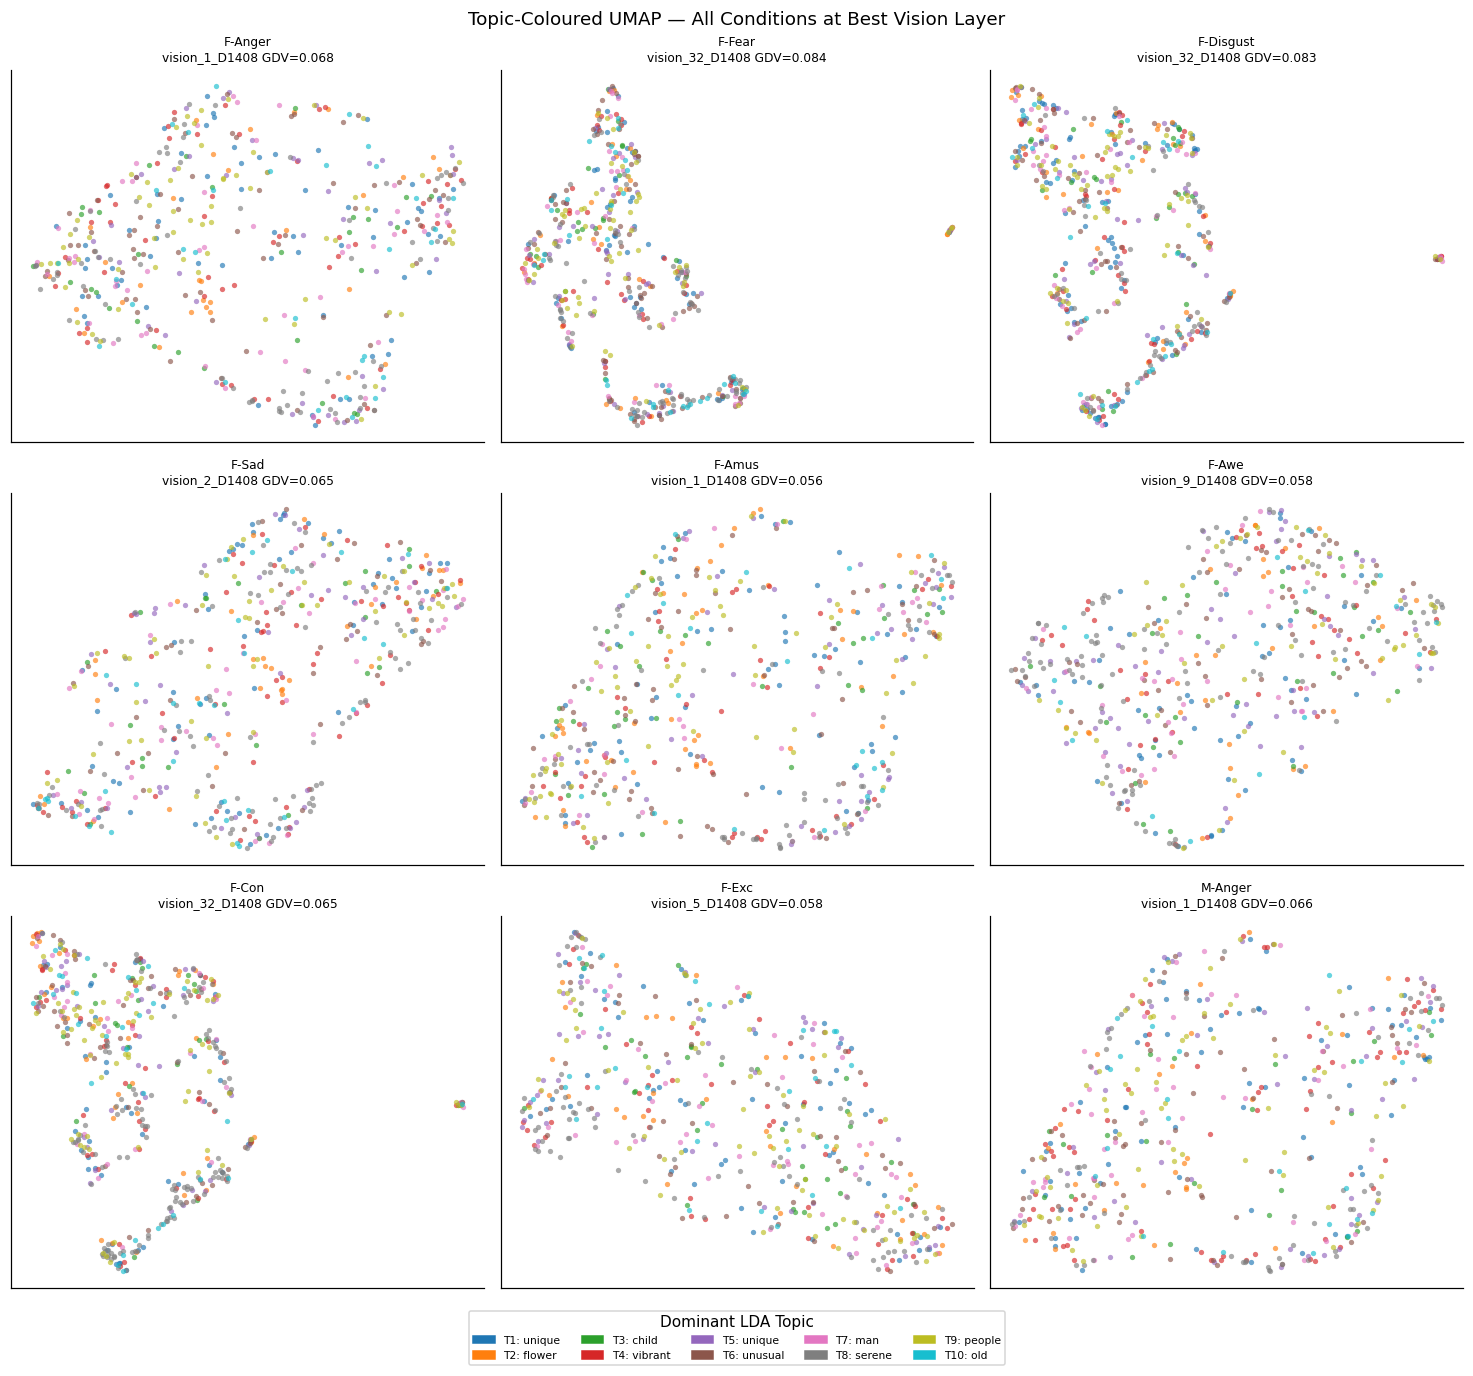

In [12]:
# All 9 conditions at their best vision layer — topic coloured
ncols = 3
nrows = (len(EXPERIMENTS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.5, nrows*4))
axes_flat  = axes.flatten()

for ax in axes_flat:
    ax.set_visible(False)

for i, exp in enumerate(EXPERIMENTS):
    ax = axes_flat[i]
    ax.set_visible(True)
    layer_key = best_vision_layer[exp]
    coords, fnames = get_projection(exp, layer_key, 'umap', 0)
    if coords is None:
        ax.set_title(f'{SHORT[exp]} — no UMAP'); continue

    sub    = df_meta[df_meta['condition'] == exp]
    fn_map = {row['filename']: int(row[topic_cols].values.argmax())
              for _, row in sub.iterrows()}
    topics_ord = [fn_map.get(fn, -1) for fn in fnames]

    for t in range(N_TOPICS):
        mask = np.array([tp == t for tp in topics_ord])
        if mask.any():
            ax.scatter(coords[mask, 0], coords[mask, 1],
                       c=[TOPIC_COLORS[t]], s=12, alpha=0.65, linewidths=0)

    gdv_val = gdv_data[exp]['gdv_per_layer'][layer_key]
    ax.set_title(f'{SHORT[exp]}\n{layer_key} GDV={gdv_val:.3f}', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

# Legend (shared)
patches = [mpatches.Patch(color=TOPIC_COLORS[t], label=f'T{t+1}: {topic_words[t][0]}')
           for t in range(N_TOPICS)]
fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=7,
           bbox_to_anchor=(0.5, -0.05), title='Dominant LDA Topic')
plt.suptitle('Topic-Coloured UMAP — All Conditions at Best Vision Layer', fontsize=12)
plt.tight_layout()
plt.savefig(f'{LDA_DIR}/nb_umap_topic_all_conditions.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 4. Layer Persistence

**Question:** at which layer does the LDA-topic structure emerge in activation
space, and how persistent is it across layers?

For each condition, we examine 5 representative layers across the vision hierarchy
plus one early language layer:

| Layer position | Key |
|----------------|-----|
| Vision early   | `vision_1_D1408` |
| Vision mid-low | `vision_9_D1408` |
| Vision mid-high| `vision_16_D1408` |
| Vision late    | `vision_32_D1408` |
| Language early | `language_1_D5120` |

**Quantitative measure:** silhouette score of LDA-topic clusters in 2-D UMAP space.
A higher silhouette → cleaner spatial separation of topic clusters.


Topic-cluster silhouette score in UMAP space (higher = cleaner spatial separation):
Layer      V-early\n(L1)  V-mid-low\n(L9)  V-mid-high\n(L16)  V-late\n(L32)  Lang-early\n(L1)
Condition                                                                                    
F-Amus            -0.115           -0.107             -0.127         -0.124            -0.161
F-Anger           -0.112           -0.106             -0.123         -0.150            -0.126
F-Awe             -0.110           -0.105             -0.113         -0.160            -0.119
F-Con             -0.121           -0.111             -0.107         -0.114            -0.151
F-Disgust         -0.133           -0.121             -0.132         -0.149            -0.142
F-Exc             -0.108           -0.102             -0.140         -0.138            -0.189
F-Fear            -0.100           -0.099             -0.141         -0.138            -0.183
F-Sad             -0.127           -0.112             -0.156         -

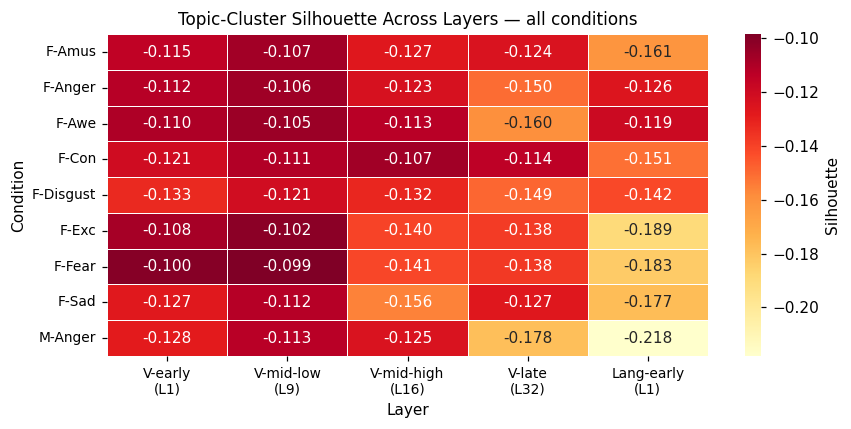

In [13]:
PROBE_LAYERS = [
    'vision_1_D1408',
    'vision_9_D1408',
    'vision_16_D1408',
    'vision_32_D1408',
    'language_1_D5120',
]
LAYER_LABELS = ['V-early\n(L1)', 'V-mid-low\n(L9)', 'V-mid-high\n(L16)',
                'V-late\n(L32)', 'Lang-early\n(L1)']

def topic_silhouette(exp, layer_key, proj_type='umap', setup_idx=0):
    """Silhouette of dominant-topic clusters in 2-D projection space."""
    coords, fnames = get_projection(exp, layer_key, proj_type, setup_idx)
    if coords is None or len(coords) < 20:
        return np.nan
    sub    = df_meta[df_meta['condition'] == exp]
    fn_map = {row['filename']: int(row[topic_cols].values.argmax())
              for _, row in sub.iterrows()}
    topic_labels = np.array([fn_map.get(fn, -1) for fn in fnames])
    valid = topic_labels >= 0
    if valid.sum() < 20:
        return np.nan
    unique_labs = np.unique(topic_labels[valid])
    if len(unique_labs) < 2:
        return np.nan
    try:
        return silhouette_score(coords[valid], topic_labels[valid])
    except Exception:
        return np.nan

# Compute silhouette for all (exp, layer) combinations
sil_df_rows = []
for exp in EXPERIMENTS:
    for lk, ll in zip(PROBE_LAYERS, LAYER_LABELS):
        sil = topic_silhouette(exp, lk)
        sil_df_rows.append({'Condition': SHORT[exp], 'Layer': ll, 'Silhouette': sil})

sil_df = pd.DataFrame(sil_df_rows).pivot(index='Condition', columns='Layer', values='Silhouette')
sil_df = sil_df[[ll for ll in LAYER_LABELS if ll in sil_df.columns]]

print("Topic-cluster silhouette score in UMAP space (higher = cleaner spatial separation):")
print(sil_df.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(sil_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=0.4, cbar_kws={'label': 'Silhouette'})
ax.set_title('Topic-Cluster Silhouette Across Layers — all conditions', fontsize=11)
ax.tick_params(axis='x', rotation=0, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig(f'{LDA_DIR}/nb_layer_persistence_silhouette.png', dpi=120, bbox_inches='tight')
plt.show()


Best overall clustering condition: F-Con (female_contentment)


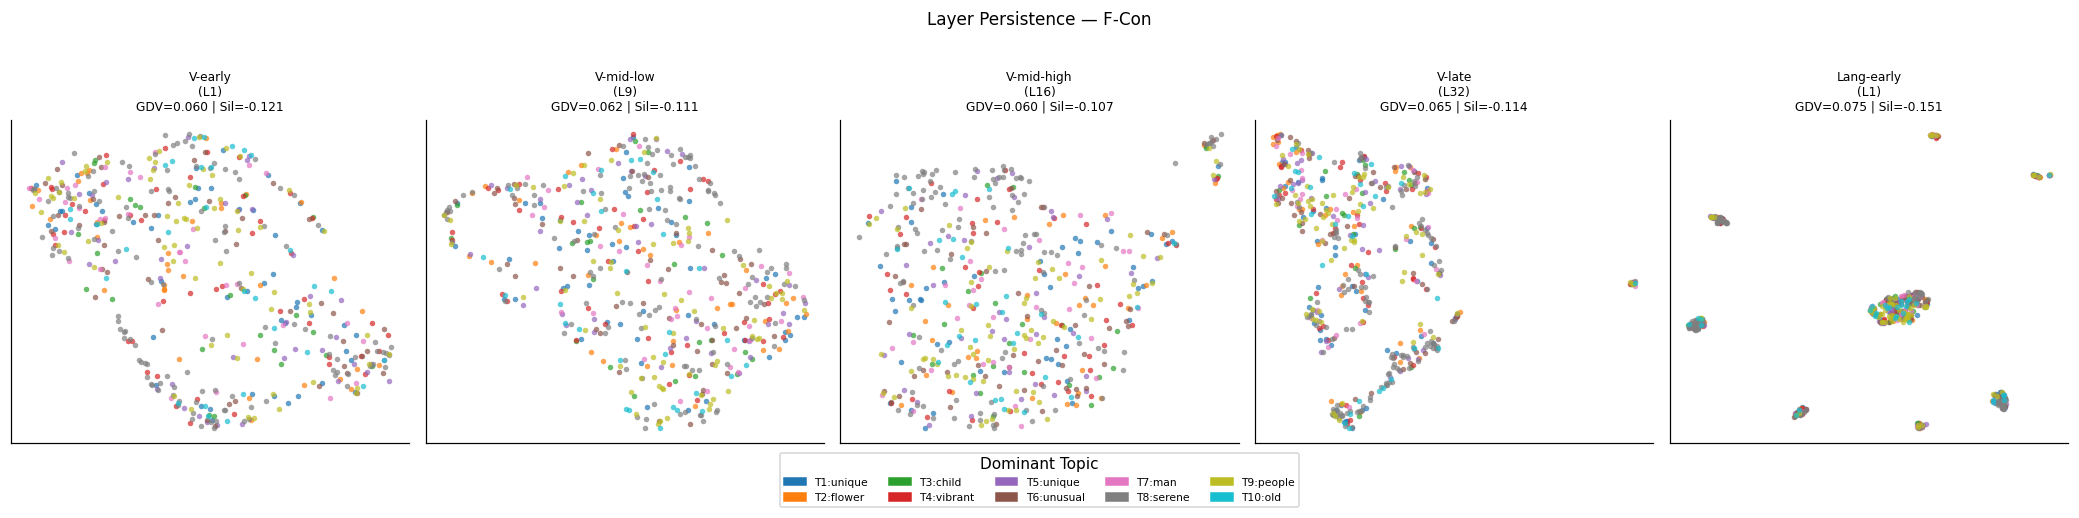

In [14]:
# Visual: topic-coloured UMAP at each probe layer for the best-clustering condition
# Pick the condition with overall highest silhouette
best_cond = sil_df.mean(axis=1).idxmax()
exp_key   = {v: k for k, v in SHORT.items()}[best_cond]
print(f"Best overall clustering condition: {best_cond} ({exp_key})")

fig, axes = plt.subplots(1, len(PROBE_LAYERS), figsize=(len(PROBE_LAYERS)*3.8, 4))

for ax, (lk, ll) in zip(axes, zip(PROBE_LAYERS, LAYER_LABELS)):
    coords, fnames = get_projection(exp_key, lk, 'umap', 0)
    if coords is None:
        ax.set_title(f'{ll}\nno data'); ax.set_visible(False); continue

    sub    = df_meta[df_meta['condition'] == exp_key]
    fn_map = {row['filename']: int(row[topic_cols].values.argmax())
              for _, row in sub.iterrows()}
    topic_labels = [fn_map.get(fn, -1) for fn in fnames]

    for t in range(N_TOPICS):
        mask = np.array([tp == t for tp in topic_labels])
        if mask.any():
            ax.scatter(coords[mask, 0], coords[mask, 1],
                       c=[TOPIC_COLORS[t]], s=13, alpha=0.7, linewidths=0)

    sil = topic_silhouette(exp_key, lk)
    gdv = gdv_data[exp_key]['gdv_per_layer'].get(lk, float('nan'))
    ax.set_title(f'{ll}\nGDV={gdv:.3f} | Sil={sil:.3f}', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

patches = [mpatches.Patch(color=TOPIC_COLORS[t], label=f'T{t+1}:{topic_words[t][0]}')
           for t in range(N_TOPICS)]
fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=7,
           bbox_to_anchor=(0.5, -0.12), title='Dominant Topic')
plt.suptitle(f'Layer Persistence — {best_cond}', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{LDA_DIR}/nb_layer_persistence_maps.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 5. Image Galleries by Topic

For each topic, we show the **top-20 images** ranked by mean topic weight
(averaged across all 9 conditions).  This is the primary visual validation:
do images within a topic actually share a unifying visual theme?

Below each gallery, the interestingness label distribution for that topic's
image set is plotted per condition — revealing how the same visual theme is
rated differently under different emotion personas.


In [15]:
def load_img_thumb(path, size=(96, 96)):
    try:
        img = Image.open(path).convert('RGB')
        img.thumbnail(size, Image.LANCZOS)
        # Pad to exact size
        out = Image.new('RGB', size, (220, 220, 220))
        x = (size[0] - img.width) // 2
        y = (size[1] - img.height) // 2
        out.paste(img, (x, y))
        return np.array(out)
    except Exception:
        return np.ones((*size, 3), dtype=np.uint8) * 180

def gallery_for_topic(topic_idx, top_n=20):
    """Show top_n images for a given topic and their label distributions."""
    t = topic_idx
    tc = f'topic_{t}'

    # Per-image mean weight for this topic
    rank = img_topic_mean[tc].sort_values(ascending=False)
    top_imgs = rank.index[:top_n].tolist()   # image_idx values

    # Map image_idx → filename
    idx2fn = df_meta[['image_idx','filename']].drop_duplicates().set_index('image_idx')['filename']
    fnames = [idx2fn[i] for i in top_imgs]

    # --- Gallery panel ---
    ncols_g = 10
    nrows_g = (top_n + ncols_g - 1) // ncols_g
    fig = plt.figure(figsize=(ncols_g*1.1, nrows_g*1.2 + 4))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[nrows_g*1.2, 3.5], hspace=0.35)
    gs_top = gridspec.GridSpecFromSubplotSpec(nrows_g, ncols_g, subplot_spec=gs[0],
                                              hspace=0.05, wspace=0.05)

    for gi, (img_idx, fn) in enumerate(zip(top_imgs, fnames)):
        ax = fig.add_subplot(gs_top[gi // ncols_g, gi % ncols_g])
        img_path = f'{IMG_DIR}/{fn}'
        thumb    = load_img_thumb(img_path)
        ax.imshow(thumb)
        wt = rank[img_idx]
        ax.set_title(f'{wt:.2f}', fontsize=5, pad=1)
        ax.axis('off')

    # Title
    top_w = ', '.join(topic_words[t][:6])
    fig.text(0.5, 0.98, f'Topic {t+1} — {top_w}',
             ha='center', va='top', fontsize=11, fontweight='bold',
             color=TOPIC_COLORS[t])

    # --- Label distribution per condition for this topic's images ---
    ax_bar = fig.add_subplot(gs[1])

    # Filter df_meta to only these top-N images
    sub = df_meta[df_meta['image_idx'].isin(top_imgs)]
    label_by_cond = sub.groupby(['condition','label']).size().unstack(fill_value=0)
    label_by_cond = label_by_cond.reindex(columns=LABEL_ORDER, fill_value=0)
    label_by_cond = label_by_cond.div(label_by_cond.sum(axis=1), axis=0) * 100

    x = np.arange(len(EXPERIMENTS))
    bottom = np.zeros(len(EXPERIMENTS))
    for lbl in LABEL_ORDER:
        if lbl not in label_by_cond.columns:
            continue
        vals = np.array([label_by_cond.loc[e, lbl] if e in label_by_cond.index else 0
                         for e in EXPERIMENTS])
        ax_bar.bar(x, vals, bottom=bottom, color=LABEL_COLORS[lbl], label=lbl[:10], width=0.65)
        bottom += vals

    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels([SHORT[e] for e in EXPERIMENTS], rotation=35, ha='right', fontsize=8)
    ax_bar.set_ylabel('% of top images', fontsize=8)
    ax_bar.set_ylim(0, 100)
    ax_bar.set_title(f'Interestingness labels for Topic {t+1} images — by condition', fontsize=9)
    ax_bar.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
    ax_bar.grid(axis='y', alpha=0.2)

    plt.savefig(f'{LDA_DIR}/nb_gallery_topic_{t+1}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Gallery saved: {LDA_DIR}/nb_gallery_topic_{t+1}.png\n")


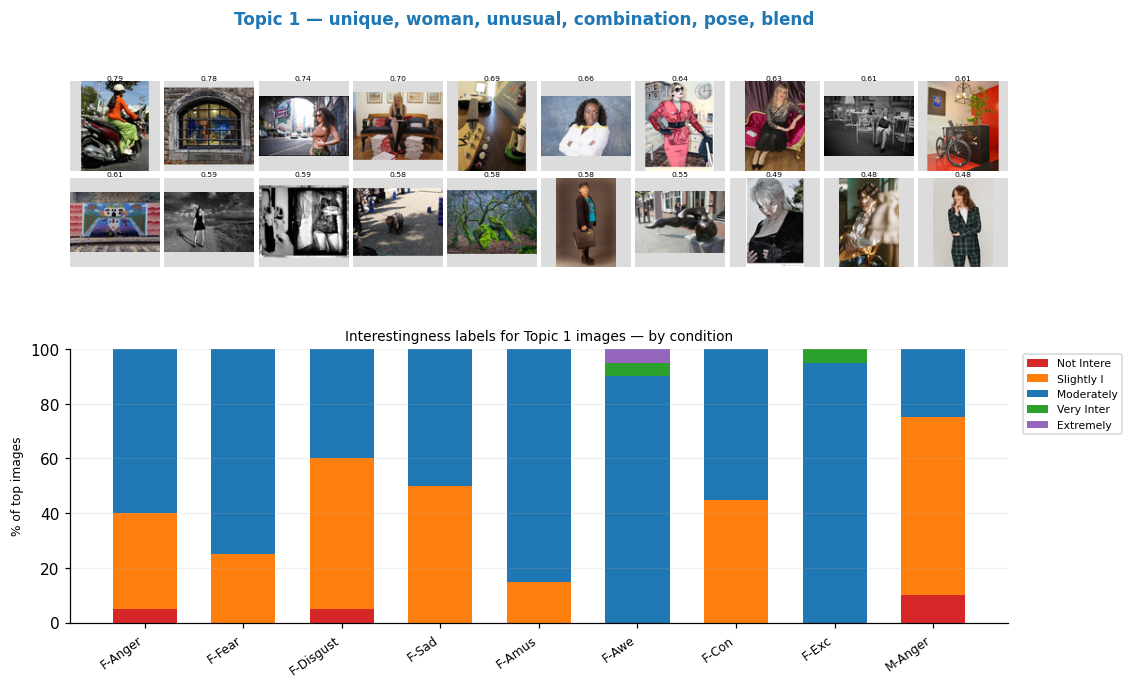

Gallery saved: results/experiments/gender_emotion_analysis/lda/nb_gallery_topic_1.png



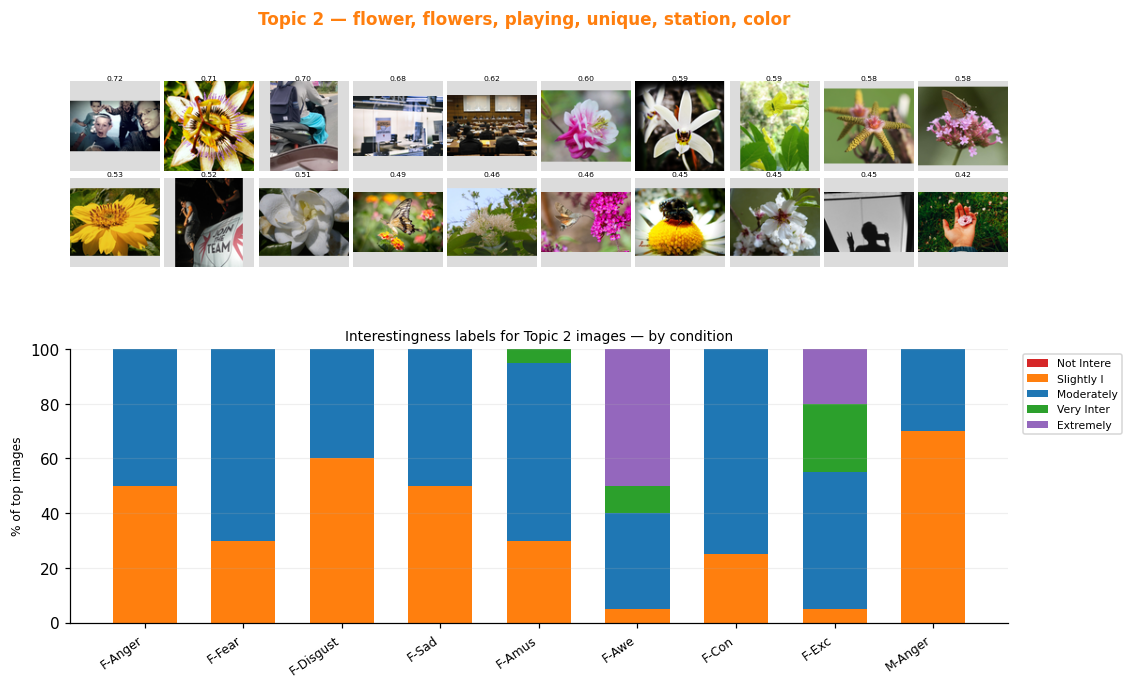

Gallery saved: results/experiments/gender_emotion_analysis/lda/nb_gallery_topic_2.png



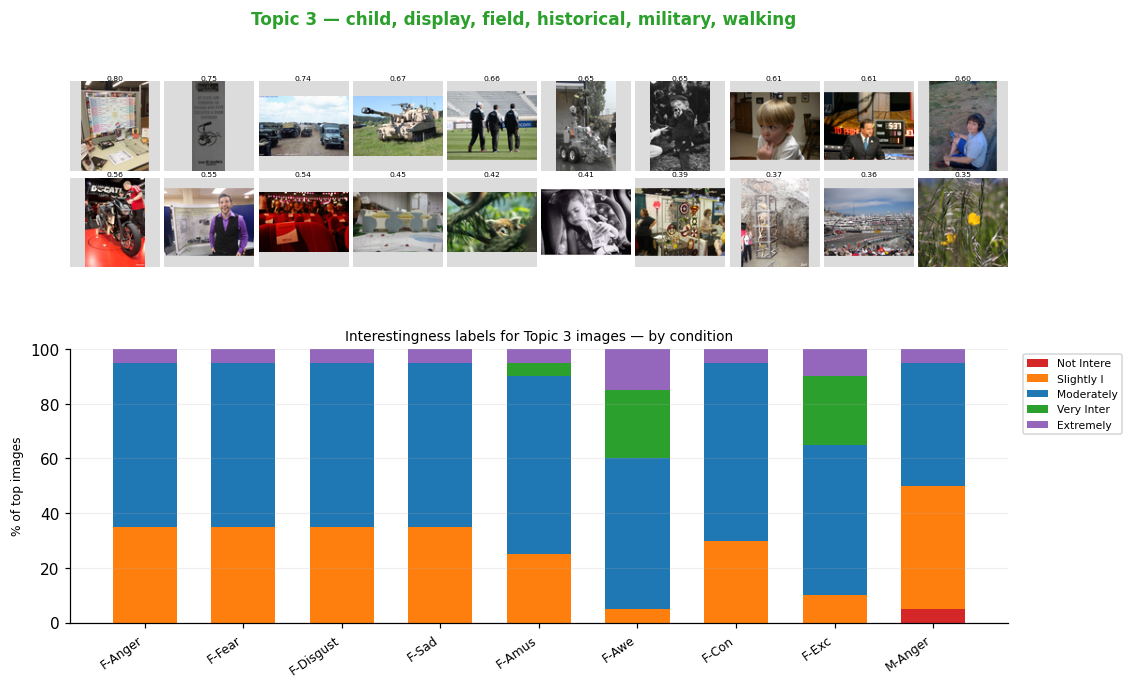

Gallery saved: results/experiments/gender_emotion_analysis/lda/nb_gallery_topic_3.png



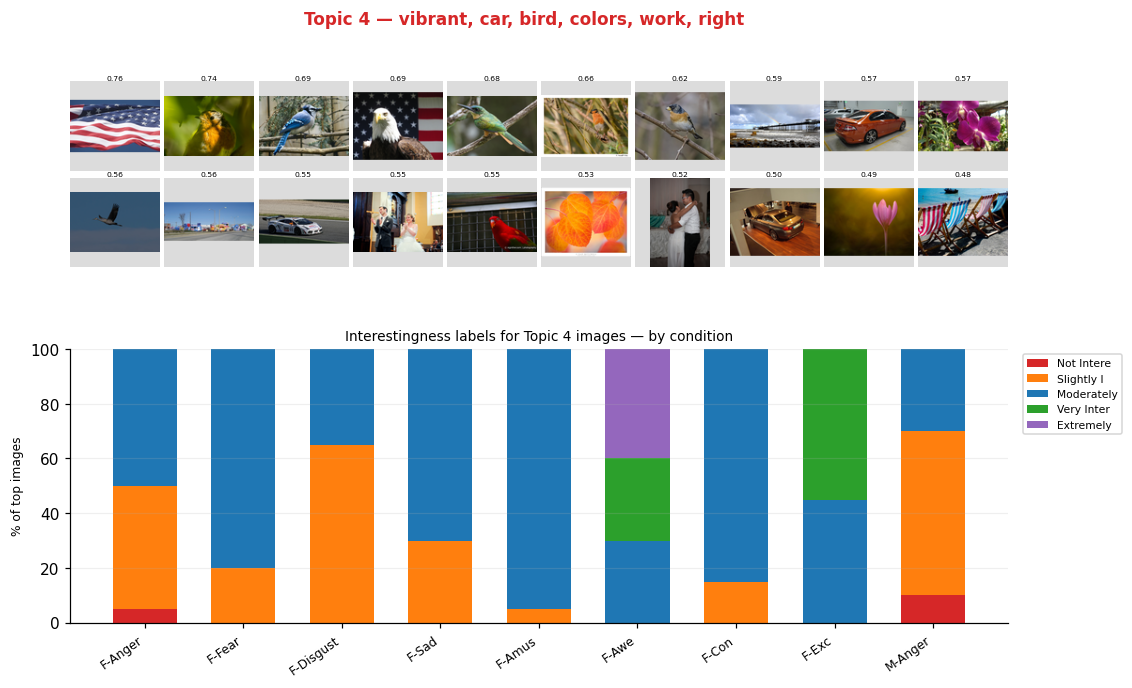

Gallery saved: results/experiments/gender_emotion_analysis/lda/nb_gallery_topic_4.png



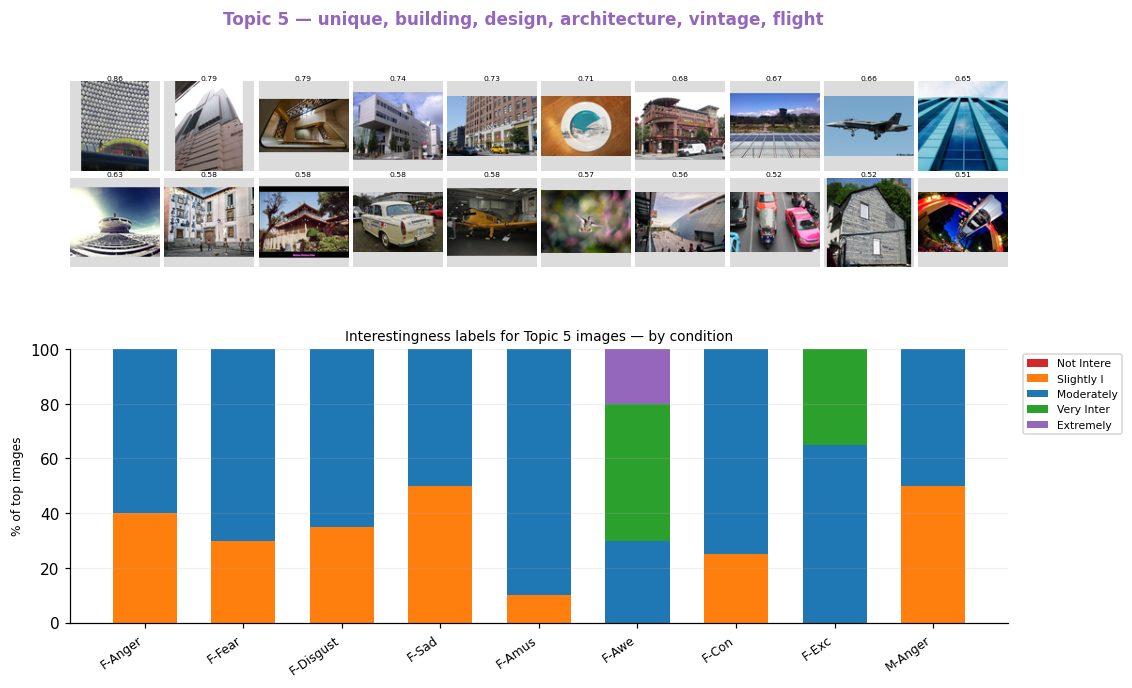

Gallery saved: results/experiments/gender_emotion_analysis/lda/nb_gallery_topic_5.png



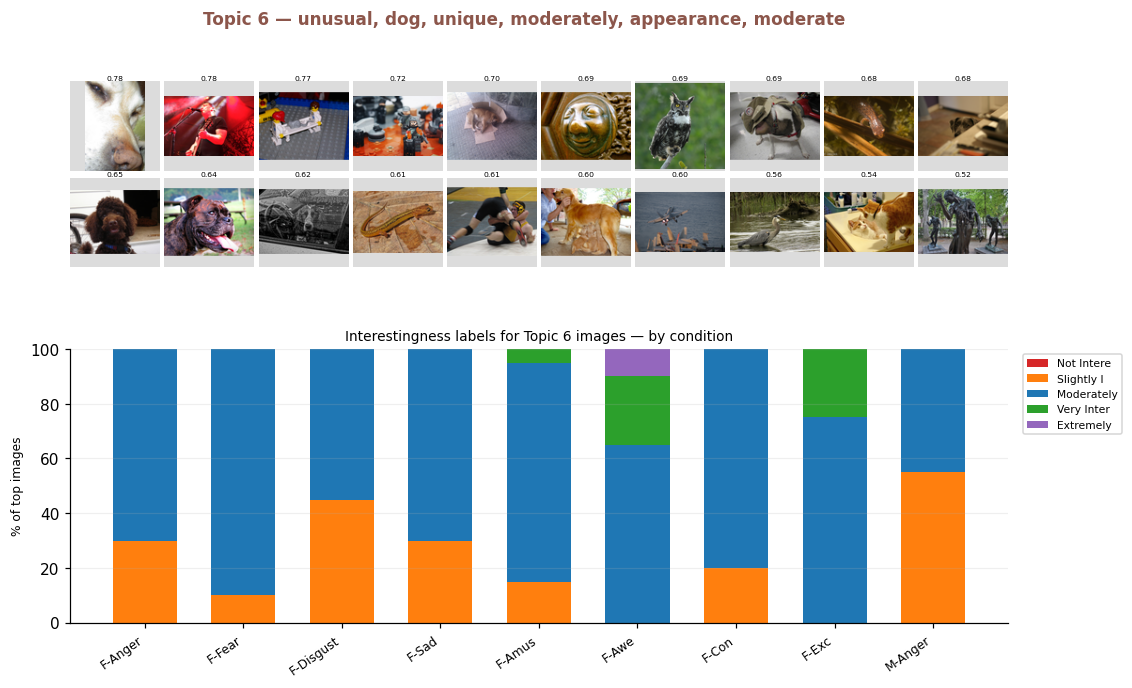

Gallery saved: results/experiments/gender_emotion_analysis/lda/nb_gallery_topic_6.png



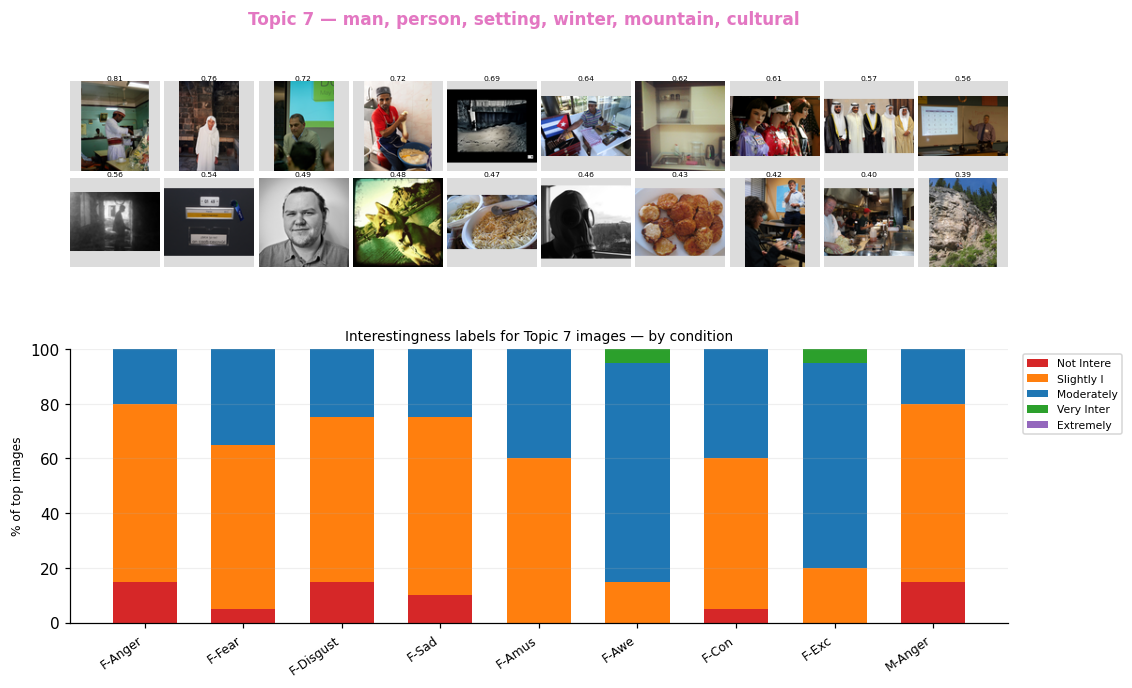

Gallery saved: results/experiments/gender_emotion_analysis/lda/nb_gallery_topic_7.png



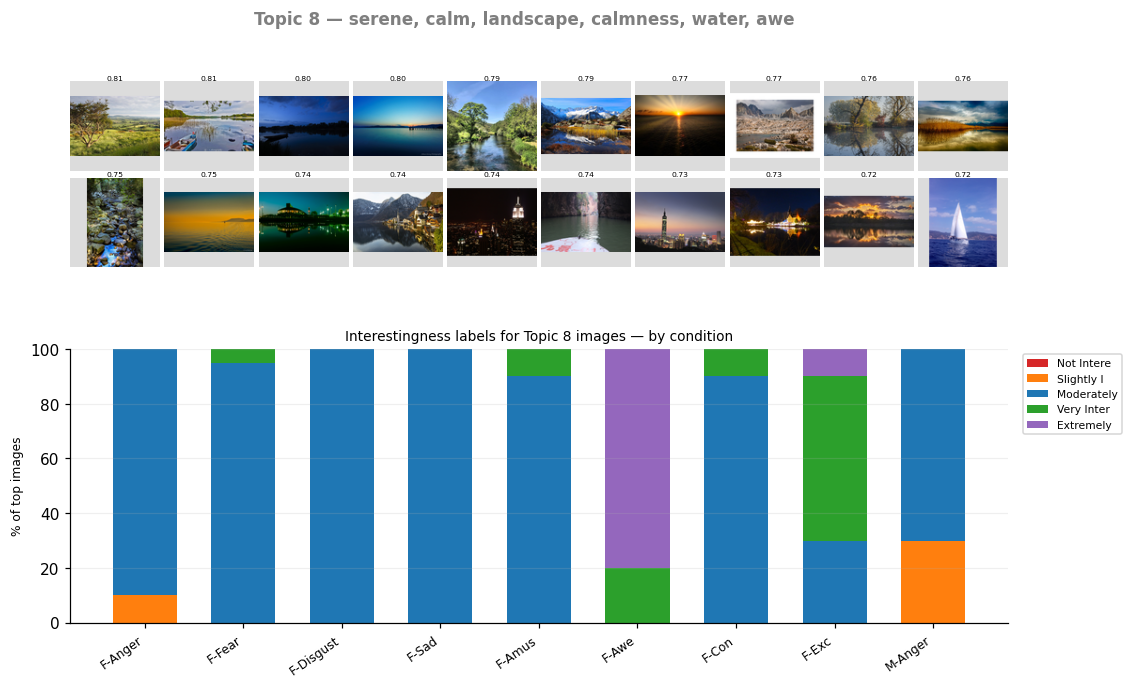

Gallery saved: results/experiments/gender_emotion_analysis/lda/nb_gallery_topic_8.png



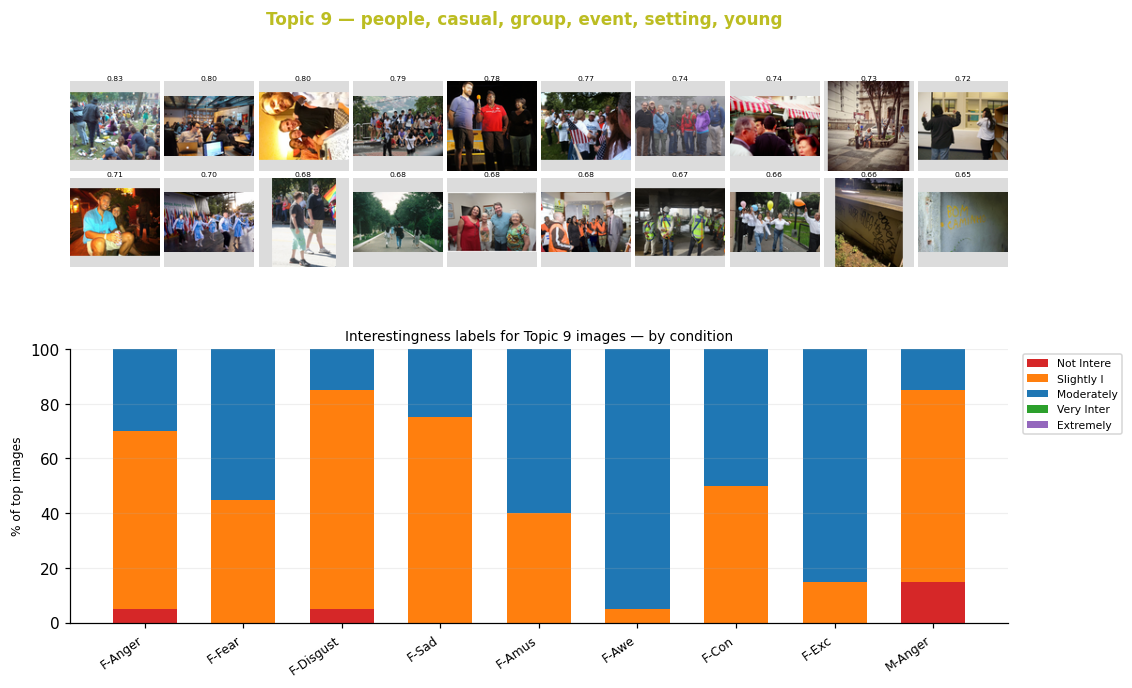

Gallery saved: results/experiments/gender_emotion_analysis/lda/nb_gallery_topic_9.png



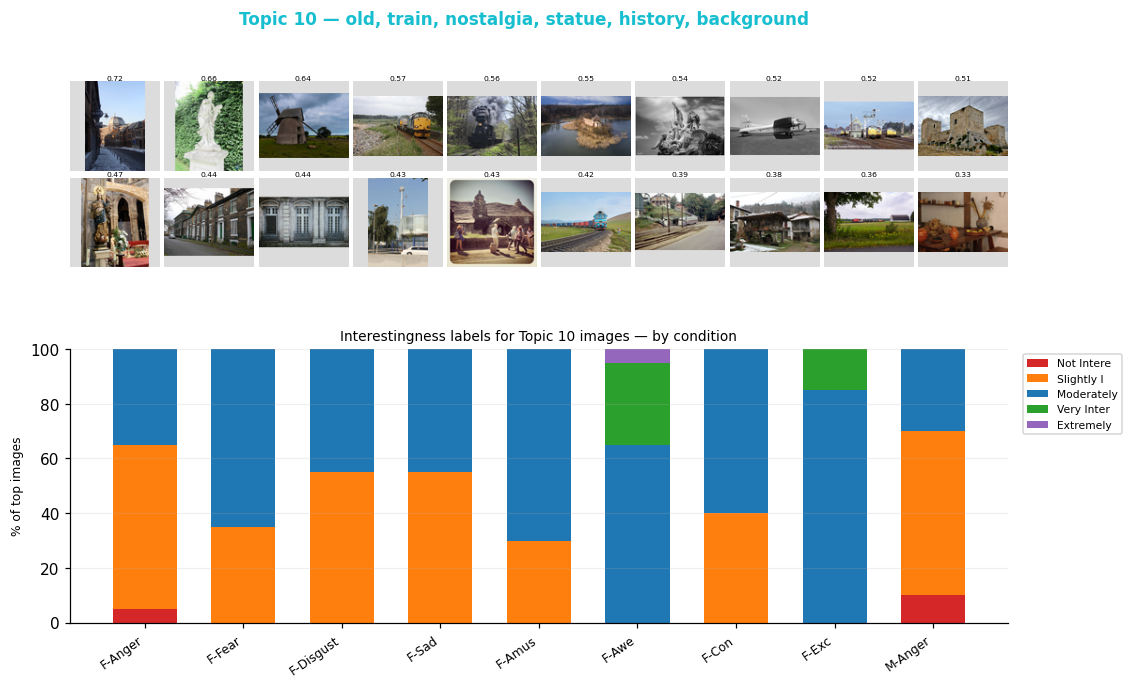

Gallery saved: results/experiments/gender_emotion_analysis/lda/nb_gallery_topic_10.png



In [16]:
# Render galleries for all topics
# (each cell produces one topic's images + label distribution)
for t in range(N_TOPICS):
    gallery_for_topic(t, top_n=20)


---
## 6. Vision-Space Validation

LDA topics were derived from **text** (the model's explanations).  This section
checks whether the same clusters appear in **visual feature space** — i.e. whether
the model's vision encoder also separates images that text descriptions put in
different topics.

### Approach
- Extract the **CLS-token activation** (vision layer 32, the last/richest vision
  layer) from one condition (female_anger — vision embeddings are condition-independent
  since the ViT processes the image before any text).
- Run **PCA** on all 500 image vectors → 2-D projection.
- Colour by dominant LDA topic.

If visual-space clusters align with topic clusters, LDA topics are capturing
genuine visual content, not just text templating artefacts.

> **Limitation:** this remains a text-derived labelling of visual clusters.
> A fully visual approach would cluster the CLS-token vectors *directly* (e.g.
> via k-means in the visual PCA space) and then inspect each cluster's images
> without any reference to the text. That is the logical next step — see the
> discussion at the end of this cell.


In [17]:
# Load vision CLS embeddings for all 500 images from female_anger
# (vision encoder output is independent of prompt)
print("Loading vision embeddings...")
ref_results = np.load(f'{GE_DIR}/results_female_anger.npy', allow_pickle=True).item()['results']
lkey = 'interestingness_label' if 'interestingness_label' in ref_results[0] else 'interestingness'

# Find available vision layer keys
sample_emb = ref_results[0]['embeddings']
vision_keys = sorted([k for k in sample_emb if 'vision' in str(k).lower()])
print("Available vision keys (first 5):", vision_keys[:5])

# Use the richest (last) vision CLS layer
rich_key = vision_keys[-1]
print(f"Using embedding key: {rich_key}")

fnames_ref = [r['filename'] for r in ref_results]
vis_embeds = np.array([np.array(r['embeddings'][rich_key]) for r in ref_results])
print(f"Vision embedding matrix: {vis_embeds.shape}")


Loading vision embeddings...


Available vision keys (first 5): ['vision_layer_0_cls', 'vision_layer_10_cls', 'vision_layer_11_cls', 'vision_layer_12_cls', 'vision_layer_13_cls']
Using embedding key: vision_layer_9_cls
Vision embedding matrix: (500, 1408)


Explained variance (PC1+PC2): 21.0%


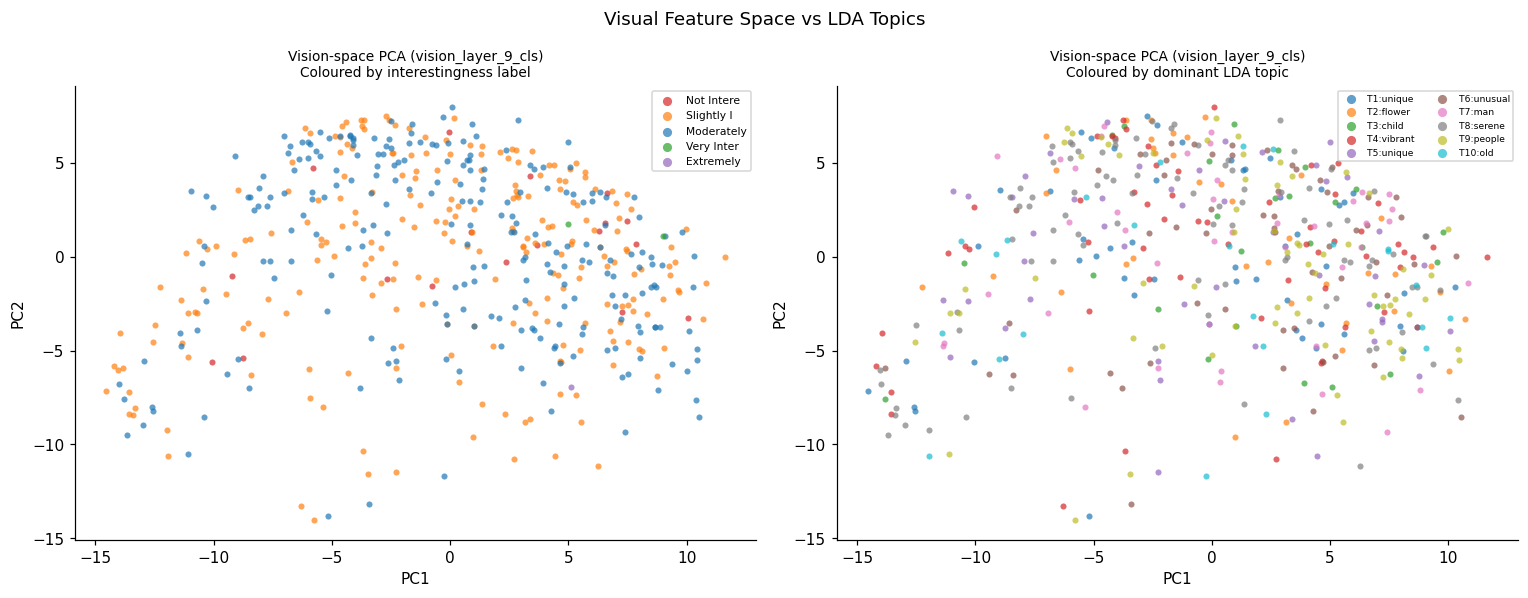

In [18]:
# PCA projection of vision embeddings
pca = PCA(n_components=2, random_state=42)
vis_2d = pca.fit_transform(vis_embeds)
print(f"Explained variance (PC1+PC2): {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Map filenames → dominant topic (image-level average)
idx2fn  = df_meta[['image_idx','filename']].drop_duplicates().set_index('image_idx')['filename']
fn2idx  = {fn: idx for idx, fn in idx2fn.items()}
fn2topic = {fn: int(img_dominant[fn2idx[fn]]) for fn in fnames_ref if fn in fn2idx}
dom_topics = np.array([fn2topic.get(fn, -1) for fn in fnames_ref])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: label coloured
labels_ref = [r[lkey] for r in ref_results]
for lbl in LABEL_ORDER:
    mask = np.array([l == lbl for l in labels_ref])
    if mask.any():
        axes[0].scatter(vis_2d[mask, 0], vis_2d[mask, 1],
                        c=LABEL_COLORS[lbl], s=16, alpha=0.7, label=lbl[:10], linewidths=0)
axes[0].set_title(f'Vision-space PCA ({rich_key})\nColoured by interestingness label', fontsize=9)
axes[0].legend(fontsize=7, markerscale=1.5)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# Right: topic coloured
valid = dom_topics >= 0
for t in range(N_TOPICS):
    mask = (dom_topics == t) & valid
    if mask.any():
        axes[1].scatter(vis_2d[mask, 0], vis_2d[mask, 1],
                        c=[TOPIC_COLORS[t]], s=16, alpha=0.7,
                        label=f'T{t+1}:{topic_words[t][0]}', linewidths=0)
axes[1].set_title(f'Vision-space PCA ({rich_key})\nColoured by dominant LDA topic', fontsize=9)
axes[1].legend(fontsize=6, markerscale=1.5, ncol=2)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.suptitle('Visual Feature Space vs LDA Topics', fontsize=12)
plt.tight_layout()
plt.savefig(f'{LDA_DIR}/nb_vision_pca_vs_topics.png', dpi=130, bbox_inches='tight')
plt.show()


In [19]:
# Quantify visual-space cluster quality for LDA topics
# (same silhouette score, but now in visual PCA space — no text involved)
valid_mask = dom_topics >= 0
n_uniq = len(np.unique(dom_topics[valid_mask]))
if n_uniq >= 2:
    sil_vis = silhouette_score(vis_2d[valid_mask], dom_topics[valid_mask])
    print(f"Silhouette of LDA topics in VISUAL PCA space: {sil_vis:.4f}")
    print()
    print("Interpretation:")
    print("  > 0.25  → strong visual alignment with LDA topics")
    print("  0.10-0.25 → moderate alignment")
    print("  < 0.10  → topics are primarily text-driven, weak visual separation")

# Per-topic: mean nearest-neighbour purity in visual space (k=10)
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=11).fit(vis_2d)
_, indices = nbrs.kneighbors(vis_2d)

purities = []
for i, (fn, ti) in enumerate(zip(fnames_ref, dom_topics)):
    if ti < 0:
        continue
    neighbour_topics = dom_topics[indices[i, 1:]]  # exclude self
    valid_nb = neighbour_topics[neighbour_topics >= 0]
    if len(valid_nb) == 0:
        continue
    purity = (valid_nb == ti).mean()
    purities.append({'topic': ti, 'purity': purity})

purity_df = pd.DataFrame(purities)
print("\nMean 10-NN purity in visual space per topic:")
for t in range(N_TOPICS):
    p = purity_df[purity_df['topic'] == t]['purity'].mean()
    print(f"  T{t+1:02d} [{topic_words[t][0]:<15}]  purity={p:.3f}")
print(f"  Overall: {purity_df['purity'].mean():.3f}")


Silhouette of LDA topics in VISUAL PCA space: -0.0994

Interpretation:
  > 0.25  → strong visual alignment with LDA topics
  0.10-0.25 → moderate alignment
  < 0.10  → topics are primarily text-driven, weak visual separation

Mean 10-NN purity in visual space per topic:
  T01 [unique         ]  purity=0.133
  T02 [flower         ]  purity=0.090
  T03 [child          ]  purity=0.035
  T04 [vibrant        ]  purity=0.121
  T05 [unique         ]  purity=0.088
  T06 [unusual        ]  purity=0.104
  T07 [man            ]  purity=0.076
  T08 [serene         ]  purity=0.217
  T09 [people         ]  purity=0.138
  T10 [old            ]  purity=0.071
  Overall: 0.124


### Discussion: moving to fully visual cluster analysis

The PCA silhouette score and NN-purity above tell us how well LDA text-derived
topics correspond to visual feature clusters.  Possible outcomes and what they mean:

| Result | Implication |
|--------|-------------|
| High visual silhouette (>0.25) | LDA topics capture genuine visual categories; text analysis is a reliable proxy |
| Low visual silhouette (<0.10) | Topics are primarily text-driven; need direct visual clustering |

**Next step for visual-first analysis:**
1. K-means (or HDBSCAN) directly on the vision CLS vectors
2. Inspect cluster centroids' nearest images visually
3. Use the k-means labels instead of LDA topics to colour UMAP projections

This removes the text entirely and grounds the theme detection purely in what
the vision encoder "sees" — avoiding any confound from the model's templated
explanation style.

The `vis_embeds` matrix computed in §6 (shape 500×1408) is already available
in this notebook and ready for direct visual clustering.


K-means (k=10) silhouette in vision PCA space: -0.0001


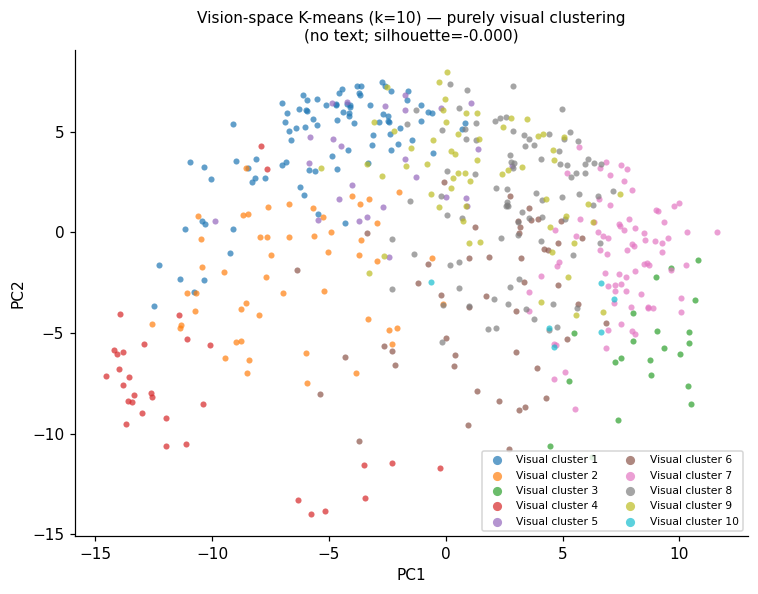


Adjusted Rand Index (LDA topics vs visual k-means): 0.0037
  ARI=1.0 → perfect agreement, ARI≈0 → independent


In [20]:
# Optional: quick k-means on vision embeddings for comparison
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

vis_scaled = StandardScaler().fit_transform(vis_embeds)
km = KMeans(n_clusters=N_TOPICS, random_state=42, n_init=10)
vis_clusters = km.fit_predict(vis_scaled)

sil_km = silhouette_score(vis_2d, vis_clusters)
print(f"K-means (k={N_TOPICS}) silhouette in vision PCA space: {sil_km:.4f}")

fig, ax = plt.subplots(figsize=(7, 5.5))
for t in range(N_TOPICS):
    mask = vis_clusters == t
    ax.scatter(vis_2d[mask, 0], vis_2d[mask, 1],
               c=[TOPIC_COLORS[t]], s=16, alpha=0.7,
               label=f'Visual cluster {t+1}', linewidths=0)
ax.set_title(f'Vision-space K-means (k={N_TOPICS}) — purely visual clustering\n'
             f'(no text; silhouette={sil_km:.3f})', fontsize=10)
ax.legend(fontsize=7, markerscale=1.5, ncol=2)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()
plt.savefig(f'{LDA_DIR}/nb_vision_kmeans.png', dpi=130, bbox_inches='tight')
plt.show()

# Agreement between LDA topics and visual k-means clusters
from sklearn.metrics import adjusted_rand_score
valid = dom_topics >= 0
ari = adjusted_rand_score(dom_topics[valid], vis_clusters[valid])
print(f"\nAdjusted Rand Index (LDA topics vs visual k-means): {ari:.4f}")
print("  ARI=1.0 → perfect agreement, ARI≈0 → independent")


---
## Summary

| Analysis | Key Finding |
|----------|-------------|
| **LDA topics** | 10 content themes derived from image descriptions, cleanly separated from evaluative scaffolding |
| **Topic assignment stability** | See §2 histogram — images with stable dominant topics across conditions are structurally unambiguous |
| **Point cloud coloring** | §3 plots show whether topic clusters are spatially coherent in UMAP |
| **Layer persistence** | §4 silhouette heatmap shows at which layer topic structure emerges in activation space |
| **Image galleries** | §5 — primary visual ground-truth; inspect whether each topic is visually coherent |
| **Vision-space validation** | §6 ARI and silhouette quantify how much text topics correspond to visual clusters |

The LDA artifacts are saved in `results/experiments/gender_emotion_analysis/lda/`
and can be reloaded for further analysis without rerunning the full pipeline.
